system_profiler SPUSBDataType | grep -A 5 -i "instek\|gds\|good will"

In [17]:
!pip install pyvisa
!pip install pyvisa_py

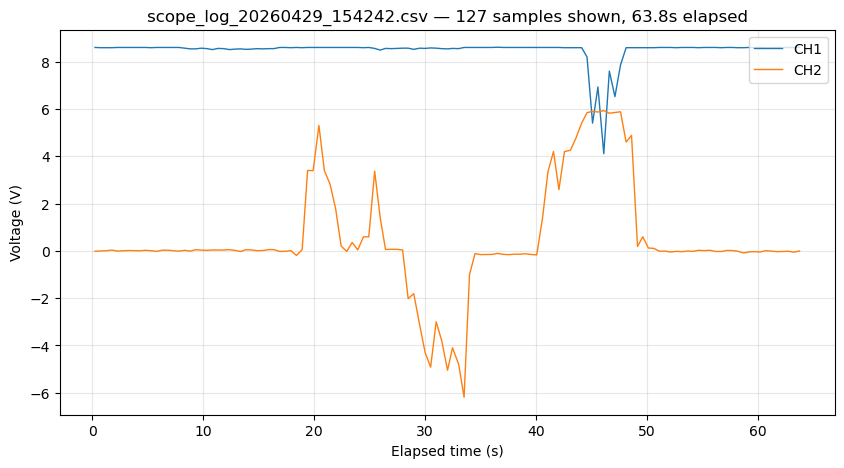

Plot stopped.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import glob
import os

# Find the most recent scope_log_*.csv automatically
log_files = sorted(glob.glob('scope_log_*.csv'), key=os.path.getmtime)
if not log_files:
    raise RuntimeError("No scope_log_*.csv files found in this directory yet.")
CSVFILE = log_files[-1]
print(f"Watching: {CSVFILE}")

REFRESH = 2.0           # seconds between plot redraws
PLOT_WINDOW = 600       # seconds of history shown (None for all)

fig, ax = plt.subplots(figsize=(10, 5))

try:
    while True:
        try:
            df = pd.read_csv(CSVFILE)
            if len(df) > 0:
                if PLOT_WINDOW is not None and df['elapsed_s'].max() > PLOT_WINDOW:
                    df = df[df['elapsed_s'] >= df['elapsed_s'].max() - PLOT_WINDOW]
                
                clear_output(wait=True)
                ax.clear()
                ax.plot(df['elapsed_s'], df.iloc[:, 2], label='CH1', linewidth=1)
                ax.plot(df['elapsed_s'], df.iloc[:, 3], label='CH2', linewidth=1)
                ax.set_xlabel('Elapsed time (s)')
                ax.set_ylabel('Voltage (V)')
                ax.set_title(f'{CSVFILE} — {len(df)} samples shown, {df["elapsed_s"].max():.1f}s elapsed')
                ax.legend(loc='upper right')
                ax.grid(True, alpha=0.3)
                display(fig)
        except (pd.errors.EmptyDataError, FileNotFoundError):
            print("Waiting for data...")
        
        time.sleep(REFRESH)
except KeyboardInterrupt:
    print("Plot stopped.")
plt.close(fig)

In [ ]:
# import usb.core
# import usb.util
# import time
# import csv
# from datetime import datetime
# from collections import deque
# import matplotlib.pyplot as plt
# from IPython.display import clear_output

# # ============ CONFIG ============
# POLL_INTERVAL = 0.1          # seconds between samples (10 Hz)
# PLOT_REFRESH = 2.0           # seconds between plot redraws
# DURATION = 2 * 3600          # total run time in seconds (2 hours)
# PLOT_WINDOW = 600            # how many seconds of history to show on plot
# MEASUREMENT = 'MEAN'         # MEAN, RMS, MAX, MIN, PK2Pk, FREQuency, etc.
# OUTFILE = f"scope_log_{datetime.now():%Y%m%d_%H%M%S}.csv"

# dev = usb.core.find(idVendor=0x2184, idProduct=0x0013)
# if dev is None:
#     raise RuntimeError("Scope not found. Is it powered on and plugged in? Might also need to go into utilities --> I/O --> computer")

# try:
#     dev.set_auto_detach_kernel_driver(True)   # <-- ADD THIS
# except (NotImplementedError, usb.core.USBError):
#     pass

# dev.set_configuration(2)


AttributeError: 'Device' object has no attribute 'set_auto_detach_kernel_driver'

In [ ]:
# # Detach any kernel driver that may have grabbed the interface
# for itf_num in [0, 1]:
#     try:
#         if dev.is_kernel_driver_active(itf_num):
#             dev.detach_kernel_driver(itf_num)
#     except (NotImplementedError, usb.core.USBError):
#         pass

# dev.set_configuration(2)
# cfg = dev.get_active_configuration()
# intf = cfg[(1, 0)]

# ep_out = usb.util.find_descriptor(
#     intf, custom_match=lambda e: usb.util.endpoint_direction(e.bEndpointAddress) == usb.util.ENDPOINT_OUT)
# ep_in = usb.util.find_descriptor(
#     intf, custom_match=lambda e: usb.util.endpoint_direction(e.bEndpointAddress) == usb.util.ENDPOINT_IN)

# def scpi_query(cmd, timeout_ms=2000):
#     """Send a SCPI command and read the reply."""
#     ep_out.write(cmd.encode() + b'\n')
#     raw = ep_in.read(256, timeout=timeout_ms)
#     return bytes(raw).decode(errors='replace').strip().rstrip('\x00').rstrip('<')

# # Sanity check
# print("Connected to:", scpi_query('*IDN?'))

# # ============ LOG LOOP + LIVE PLOT ============
# # Rolling buffers for the plot (deques drop old samples automatically)
# maxlen = int(PLOT_WINDOW / POLL_INTERVAL)
# t_buf = deque(maxlen=maxlen)
# ch1_buf = deque(maxlen=maxlen)
# ch2_buf = deque(maxlen=maxlen)

# fig, ax = plt.subplots(figsize=(10, 5))
# last_plot = 0
# start = time.time()

# with open(OUTFILE, 'w', newline='') as f:
#     w = csv.writer(f)
#     w.writerow(['elapsed_s', 'timestamp', f'ch1_{MEASUREMENT}_V', f'ch2_{MEASUREMENT}_V'])
    
#     try:
#         while (time.time() - start) < DURATION:
#             loop_start = time.time()
#             try:
#                 # Query both channels. GDS-2000A SCPI: :MEASure:SOURce<n>:<TYPE>?
#                 ch1 = float(scpi_query(f':MEASure:SOURce1 CH1;:MEASure:{MEASUREMENT}?'))
#                 ch2 = float(scpi_query(f':MEASure:SOURce1 CH2;:MEASure:{MEASUREMENT}?'))
                
#                 elapsed = time.time() - start
#                 w.writerow([f'{elapsed:.3f}', datetime.now().isoformat(), ch1, ch2])
#                 f.flush()
                
#                 t_buf.append(elapsed)
#                 ch1_buf.append(ch1)
#                 ch2_buf.append(ch2)
                
#                 # Refresh plot every PLOT_REFRESH seconds
#                 if (time.time() - last_plot) >= PLOT_REFRESH:
#                     clear_output(wait=True)
#                     ax.clear()
#                     ax.plot(t_buf, ch1_buf, label='CH1', linewidth=1)
#                     ax.plot(t_buf, ch2_buf, label='CH2', linewidth=1)
#                     ax.set_xlabel('Elapsed time (s)')
#                     ax.set_ylabel(f'{MEASUREMENT} voltage (V)')
#                     ax.set_title(f'Live scope log — {elapsed:.0f}s elapsed, {len(t_buf)} samples shown')
#                     ax.legend(loc='upper right')
#                     ax.grid(True, alpha=0.3)
#                     display(fig)
#                     last_plot = time.time()
                    
#             except usb.core.USBError as e:
#                 print(f'USB error at {time.time()-start:.1f}s: {e}')
#                 time.sleep(0.5)
#                 continue
#             except ValueError as e:
#                 # Scope occasionally returns garbage during fast polling — skip
#                 print(f'Parse error at {time.time()-start:.1f}s: {e}')
#                 continue
            
#             # Maintain the polling cadence
#             elapsed_in_loop = time.time() - loop_start
#             sleep_time = POLL_INTERVAL - elapsed_in_loop
#             if sleep_time > 0:
#                 time.sleep(sleep_time)
    
#     except KeyboardInterrupt:
#         print(f'\nStopped manually at {time.time()-start:.1f}s')

# print(f'\nDone. Logged {len(t_buf)} samples to {OUTFILE}')
# plt.close(fig)

USBError: [Errno 13] Access denied (insufficient permissions)

In [ ]:
# import usb.core
# import usb.util

# dev = usb.core.find(idVendor=0x2184, idProduct=0x0013)
# dev.set_configuration(2)   # explicitly select config 2

# # Find the CDC Data interface (interface 1) and grab its endpoints
# cfg = dev.get_active_configuration()
# intf = cfg[(1, 0)]   # interface 1, alt setting 0

# ep_out = usb.util.find_descriptor(
#     intf, custom_match=lambda e: usb.util.endpoint_direction(e.bEndpointAddress) == usb.util.ENDPOINT_OUT)
# ep_in = usb.util.find_descriptor(
#     intf, custom_match=lambda e: usb.util.endpoint_direction(e.bEndpointAddress) == usb.util.ENDPOINT_IN)

# # Send *IDN? and read response
# ep_out.write(b'*IDN?\n')
# response = ep_in.read(256, timeout=2000)
# print(bytes(response).decode(errors='replace'))


GW,GDS-2302A,GET190100,V1.30



In [ ]:
import usb.core
dev = usb.core.find(idVendor=0x2184, idProduct=0x0013)
print(dev)


DEVICE ID 2184:0013 on Bus 001 Address 001 =================
 bLength                :   0x12 (18 bytes)
 bDescriptorType        :    0x1 Device
 bcdUSB                 :  0x200 USB 2.0
 bDeviceClass           :    0x2 Communications Device
 bDeviceSubClass        :    0x0
 bDeviceProtocol        :    0x0
 bMaxPacketSize0        :   0x40 (64 bytes)
 idVendor               : 0x2184
 idProduct              : 0x0013
 bcdDevice              :  0x226 Device 2.26
 iManufacturer          :    0x1 GW
 iProduct               :    0x2 GDS-2302A
 iSerialNumber          :    0x3 GET190100
 bNumConfigurations     :    0x1
  CONFIGURATION 2: 2 mA ====================================
   bLength              :    0x9 (9 bytes)
   bDescriptorType      :    0x2 Configuration
   wTotalLength         :   0x43 (67 bytes)
   bNumInterfaces       :    0x2
   bConfigurationValue  :    0x2
   iConfiguration       :    0x5 Gadget Serial CDC ACM
   bmAttributes         :   0xc0 Self Powered
   bMaxPower         

In [ ]:
# import pyvisa
# rm = pyvisa.ResourceManager('@py')
# print(rm.visalib.get_debug_info())


OrderedDict({'Version': '0.8.1', 'USB INSTR': 'Available via PyUSB (1.3.1). Backend: libusb1', 'USB RAW': 'Available via PyUSB (1.3.1). Backend: libusb1', 'TCPIP INSTR': 'Available \n         Resource discovery:\n         - VXI-11: ok\n         - hislip: disabled (zeroconf not installed)', 'TCPIP SOCKET': 'Available ', 'PRLGX_TCPIP INTFC': 'Available ', 'GPIB INSTR': 'Available ', 'ASRL INSTR': ['Please install PySerial (>=3.0) to use this resource type.', "No module named 'serial'"], 'VICP INSTR': ['Please install PyVICP to use this resource type.'], 'PRLGX_ASRL INTFC': ['Please install PySerial (>=3.0) to use this resource type.', "No module named 'serial'"], 'GPIB INTFC': ['Please install linux-gpib (Linux) or gpib-ctypes (Windows, Linux) to use this resource type. Note that installing gpib-ctypes will give you access to a broader range of functionalities.', "No module named 'gpib'"]})


In [ ]:
# import pyvisa
# rm = pyvisa.ResourceManager('@py')
# print(rm.list_resources())


()


/opt/miniconda3/lib/python3.13/site-packages/pyvisa_py/tcpip.py:122: UserWarning: TCPIP::hislip resource discovery requires the zeroconf package to be installed... try 'pip install zeroconf'
  warnings.warn(
